# Habit Tracking — Statistical Analysis
Katy Yut  
March 20, 2026

## Goals
Investigate correlations and potential causal relationships between daily habits and mental health (rated 1–10).

**Key questions:**
1. Does exercise make me feel better?
2. Do I make my bed more often when I was sober the day before?
3. Does dancing make me happier?
4. Do drugs (alcohol/weed) have a negative impact on mental health?

## Statistical Approach
| Test | When used |
|---|---|
| Point-biserial correlation | Boolean habit vs continuous Mental_Health |
| Mann-Whitney U | Compare Mental_Health distributions (habit done vs not done) |
| OLS + HAC standard errors | All habits simultaneously predicting Mental_Health, autocorrelation-robust |
| Lagged DV (MH_lag1) | Control for autocorrelation in mood — yesterday's mood predicts today's |
| ADF test | Confirm Mental_Health series is stationary before running OLS |
| Lagged correlation | Yesterday's habit vs today's outcome |
| Reverse causality check | Does low mood yesterday predict substance use today? |
| Pearson correlation | Habit-habit associations (treating booleans as 0/1) |

## Assumptions & Caveats
- **Observational data only**: correlation ≠ causation. Lagged effects strengthen causal arguments but cannot prove them.
- **Analysis restricted to active tracking period** (`HT_START_DATE = 2022-06-17`) to avoid bias from sparse early data.
- **Mental_Health is ordinal** (1–10 integer) but treated as continuous here. Results should be interpreted accordingly.
- **Multiple comparisons**: with ~15 habits tested, some significant p-values will be false positives. Bonferroni-corrected threshold is noted.
- **Missing data** (`NaN` in Mental_Health): rows with missing outcomes are dropped per-analysis, not imputed.
- **Weak exogeneity**: we assume habits today are not reactions to mood earlier *that same morning* — morning mood could affect whether you exercise, which would make habits endogenous.
- **Stationarity**: we assume Mental_Health has a roughly constant mean and variance over the tracking window. Confirmed via ADF test in Section 5.
- **No structural breaks**: we assume no single life event (job change, move, new medication) permanently shifted the habit-mood relationship. Year-over-year plots in Section 8 provide a visual check.
- **Linearity of dosage**: we assume one beer has the same marginal effect as five. Caffeine_Quantity_mg is the only quantitative dosage variable available; all other substance habits are binary.


---
# 0. Setup

In [49]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests

from habit_tracking.tracker import HabitTracker
from habit_tracking import config

# Consistent visual style
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
PALETTE = sns.color_palette('muted')

print('Packages loaded.')

Packages loaded.


In [50]:
tracker = HabitTracker()
tracker.load_and_clean()

print(f'Full dataset: {len(tracker.df):,} rows ({tracker.df.Date.min()} → {tracker.df.Date.max()})')

Full dataset: 2,712 rows (2018-10-22 → 2026-03-23)


---
# 1. Data Preparation

Use the same pipeline as the Streamlit app: `tracker.plot_prep(start_date=config.HT_START_DATE)` filters `tracker.df` to the active tracking window (2022-06-17 onward) and builds `tracker.df_long` and monthly aggregates.  
We then further restrict to days where a form was actually submitted (`Tracked_Habits == True`), since back-filled `False` values before first submission would distort correlations.

In [51]:
# ── Use tracker.plot_prep() — same pipeline as the Streamlit app ─────────────
# This: (1) builds tracker.df_long, (2) filters tracker.df to HT_START_DATE,
# (3) aggregates monthly stats into tracker.df_monthly_perc / tracker.df_monthly_raw
tracker.plot_prep(start_date=config.HT_START_DATE)

# Only keep days where a form was actually submitted that day
# (Tracked_Habits == True means Submission_DateTime matches the Date)
df = tracker.df[tracker.df['Tracked_Habits'] == True].copy()
df = df.reset_index(drop=True)

# ── Define habit columns ──────────────────────────────────────────────────────
# All boolean habits from config.NA_AS_TRUE; Delta8 excluded because
# COMBINE_D8_WEED=True merges it into Weed inside load_and_clean()
HABIT_COLS = [col for col in config.NA_AS_TRUE.keys() if col in df.columns]
OUTCOME = 'Mental_Health'

# ── Build analysis-ready dataframe ────────────────────────────────────────────
# Cast booleans to int (0/1) — required for point-biserial correlation and OLS.
# Convert Date to Timestamp once here so .dt accessor works throughout.
df_int = df[HABIT_COLS + [OUTCOME, 'Date']].copy()
df_int['Date'] = pd.to_datetime(df_int['Date'])
for col in HABIT_COLS:
    df_int[col] = df_int[col].astype(int)
df_int[OUTCOME] = pd.to_numeric(df_int[OUTCOME], errors='coerce')

# Derive Year/Month from the now-Timestamp Date column; add Season
df_int['Year']   = df_int['Date'].dt.year
df_int['Month']  = df_int['Date'].dt.month
df_int['Season'] = df_int['Month'].map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Fall',   10: 'Fall',  11: 'Fall',
})

n_tracked = len(df_int)
n_with_mh = df_int[OUTCOME].notna().sum()
print(f'Active tracking days: {n_tracked:,}')
print(f'Days with Mental_Health score: {n_with_mh:,} ({100*n_with_mh/n_tracked:.1f}%)')
print(f'\nMental Health distribution:')
print(df_int[OUTCOME].describe().round(2))

Active tracking days: 1,229
Days with Mental_Health score: 1,227 (99.8%)

Mental Health distribution:
count    1227.00
mean        5.52
std         1.42
min         1.00
25%         5.00
50%         6.00
75%         6.00
max        10.00
Name: Mental_Health, dtype: float64


---
# 2. Descriptive Overview

Before any inferential statistics, understand the marginal distributions.

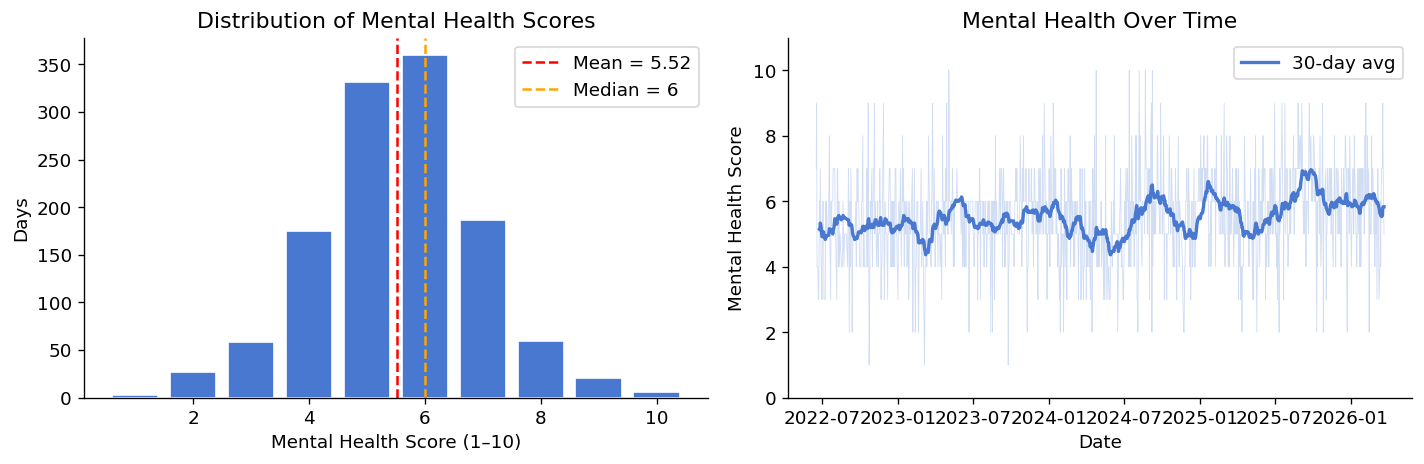

In [52]:
# ── Mental Health distribution ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

mh = df_int[OUTCOME].dropna()

# Histogram
axes[0].hist(mh, bins=range(1, 12), align='left', edgecolor='white', color=PALETTE[0], rwidth=0.8)
axes[0].set_xlabel('Mental Health Score (1–10)')
axes[0].set_ylabel('Days')
axes[0].set_title('Distribution of Mental Health Scores')
axes[0].axvline(mh.mean(), color='red', linestyle='--', label=f'Mean = {mh.mean():.2f}')
axes[0].axvline(mh.median(), color='orange', linestyle='--', label=f'Median = {mh.median():.0f}')
axes[0].legend()

# Rolling 30-day average over time
ts = df_int[['Date', OUTCOME]].dropna().set_index('Date').sort_index()
rolling = ts[OUTCOME].rolling(30, min_periods=7).mean()
axes[1].plot(ts.index, ts[OUTCOME], alpha=0.25, color=PALETTE[0], linewidth=0.5)
axes[1].plot(rolling.index, rolling, color=PALETTE[0], linewidth=2, label='30-day avg')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Mental Health Score')
axes[1].set_title('Mental Health Over Time')
axes[1].set_ylim(0, 11)
axes[1].legend()

plt.tight_layout()
plt.show()

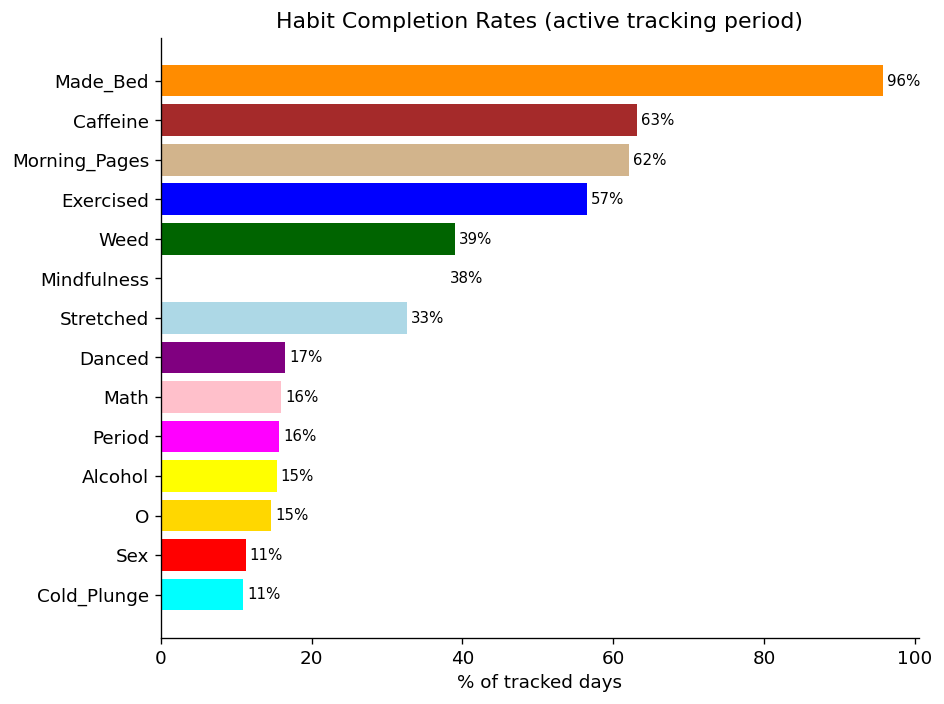

In [53]:
# ── Habit completion rates ─────────────────────────────────────────────────────
habit_rates = df_int[HABIT_COLS].mean().sort_values(ascending=True) * 100

fig, ax = plt.subplots(figsize=(8, 6))
colors = [config.VAR_COLORS.get(h, 'steelblue') for h in habit_rates.index]
bars = ax.barh(habit_rates.index, habit_rates.values, color=colors, edgecolor='none')
ax.set_xlabel('% of tracked days')
ax.set_title('Habit Completion Rates (active tracking period)')
for bar, val in zip(bars, habit_rates.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{val:.0f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

---
# 3. Habit → Mental Health Correlations

**Method:** Point-biserial correlation (equivalent to Pearson when one variable is binary 0/1).  
Additionally, Mann-Whitney U test checks whether the Mental_Health *distributions* differ significantly between habit-done and habit-not-done days.  

**Multiple comparisons:** With 14 habits, expect ~0.7 false positives at α=0.05 by chance alone.  
Bonferroni-corrected threshold: α_adjusted = 0.05 / 14 ≈ **0.0036**.  
We also show Benjamini-Hochberg (BH) corrected p-values, which are less conservative.

In [54]:
results = []
analysis_df = df_int.dropna(subset=[OUTCOME])

for habit in HABIT_COLS:
    done     = analysis_df.loc[analysis_df[habit] == 1, OUTCOME]
    not_done = analysis_df.loc[analysis_df[habit] == 0, OUTCOME]

    if len(done) < 10 or len(not_done) < 10:
        continue

    r, _       = stats.pointbiserialr(analysis_df[habit], analysis_df[OUTCOME])
    _, p_mw    = stats.mannwhitneyu(done, not_done, alternative='two-sided')

    results.append({
        'Habit':           habit,
        'N_done':          len(done),
        'MH_done_mean':    done.mean(),
        'MH_not_done_mean': not_done.mean(),
        'MH_diff':         done.mean() - not_done.mean(),
        'r':               r,
        'p_mannwhitney':   p_mw,
    })

results_df = pd.DataFrame(results)
_, p_bh, _, _ = multipletests(results_df['p_mannwhitney'], method='fdr_bh')
results_df['p_BH']   = p_bh
results_df['sig_BH'] = results_df['p_BH'] < 0.05
results_df = results_df.sort_values('MH_diff', ascending=False).reset_index(drop=True)

print(results_df[['Habit','N_done','MH_done_mean','MH_not_done_mean','MH_diff','r','p_mannwhitney','p_BH','sig_BH']].round(3).to_string(index=False))

        Habit  N_done  MH_done_mean  MH_not_done_mean  MH_diff      r  p_mannwhitney  p_BH  sig_BH
       Danced     203         6.133             5.401    0.732  0.191          0.000 0.000    True
            O     180         6.011             5.438    0.573  0.142          0.000 0.000    True
     Caffeine     775         5.725             5.175    0.550  0.186          0.000 0.000    True
         Math     196         5.969             5.437    0.532  0.137          0.000 0.000    True
          Sex     138         5.978             5.465    0.514  0.114          0.000 0.000    True
         Weed     479         5.766             5.366    0.400  0.137          0.000 0.000    True
    Stretched     401         5.783             5.396    0.387  0.128          0.000 0.000    True
    Exercised     695         5.666             5.335    0.332  0.115          0.000 0.000    True
  Cold_Plunge     134         5.664             5.505    0.159  0.035          0.145 0.202   False
      Alco

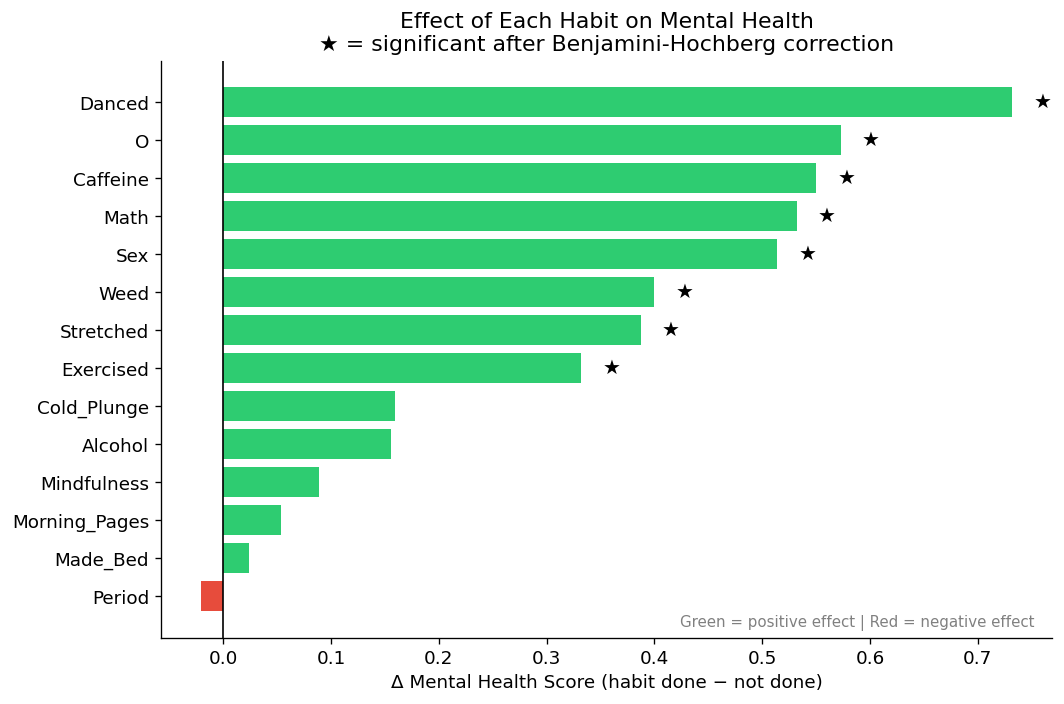

In [55]:
# ── Forest plot: mean Mental_Health difference (done − not done) ───────────────
fig, ax = plt.subplots(figsize=(9, 6))

sorted_df = results_df.sort_values('MH_diff')
colors_bar = ['#2ecc71' if d > 0 else '#e74c3c' for d in sorted_df['MH_diff']]

bars = ax.barh(sorted_df['Habit'], sorted_df['MH_diff'], color=colors_bar, edgecolor='none')
ax.axvline(0, color='black', linewidth=1)

# Mark statistically significant results
for _, row in sorted_df.iterrows():
    if row['sig_BH']:
        y_pos = list(sorted_df['Habit']).index(row['Habit'])
        ax.text(row['MH_diff'] + (0.02 if row['MH_diff'] > 0 else -0.02),
                y_pos, '★', va='center',
                ha='left' if row['MH_diff'] > 0 else 'right', fontsize=12)

ax.set_xlabel('Δ Mental Health Score (habit done − not done)')
ax.set_title('Effect of Each Habit on Mental Health\n★ = significant after Benjamini-Hochberg correction')
ax.text(0.98, 0.02, 'Green = positive effect | Red = negative effect',
        transform=ax.transAxes, ha='right', fontsize=9, color='grey')
plt.tight_layout()
plt.show()

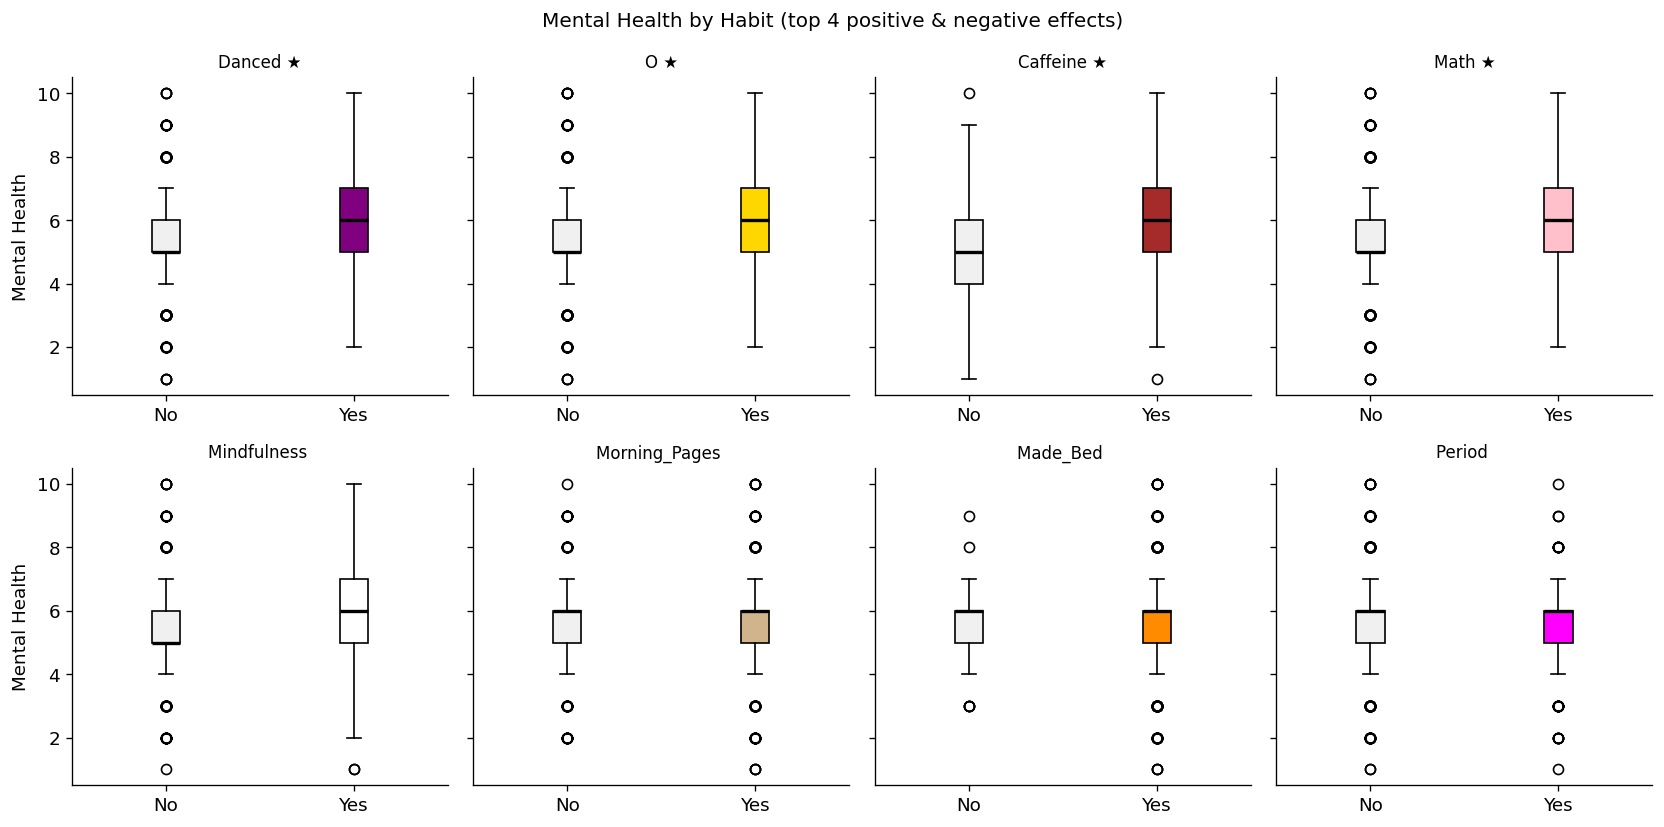

In [56]:
# ── Box plots: Mental_Health distributions for top/bottom habits ───────────────
# Show top 4 positive and top 4 negative by MH_diff
top_habits = list(results_df.head(4)['Habit']) + list(results_df.tail(4)['Habit'])

fig, axes = plt.subplots(2, 4, figsize=(14, 7), sharey=True)
axes = axes.flatten()

for ax, habit in zip(axes, top_habits):
    sub = analysis_df[['Date', habit, OUTCOME]].dropna()
    groups = [sub.loc[sub[habit] == 0, OUTCOME], sub.loc[sub[habit] == 1, OUTCOME]]
    bp = ax.boxplot(groups, labels=['No', 'Yes'], patch_artist=True,
                    medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor('#f0f0f0')
    bp['boxes'][1].set_facecolor(config.VAR_COLORS.get(habit, 'steelblue'))

    row = results_df.loc[results_df['Habit'] == habit].iloc[0]
    sig = '★' if row['sig_BH'] else ''
    ax.set_title(f'{habit} {sig}', fontsize=10)
    ax.set_ylabel('Mental Health') if ax in axes[::4] else None
    ax.set_ylim(0.5, 10.5)

fig.suptitle('Mental Health by Habit (top 4 positive & negative effects)', fontsize=12)
plt.tight_layout()
plt.show()

---
# 4. Lagged Effects — Yesterday's Habits Today

Lagged analysis is a simple observational tool for building causal arguments:  
if habit on day *t* predicts mental health on day *t+1* (or behavior on day *t+1*), that's stronger evidence of a directional effect than same-day correlation.

**Key questions addressed here:**
- Does being **sober yesterday** (no Alcohol/Weed) predict making your bed today?
- Do drugs yesterday predict lower mental health today?
- Does exercise yesterday predict higher mental health today?

In [57]:
# ── Build lagged dataset ───────────────────────────────────────────────────────
lag_df = df_int.sort_values('Date').copy()

for col in HABIT_COLS:
    lag_df[f'{col}_lag1'] = lag_df[col].shift(1)

# Null out lags that cross a gap in tracking (non-consecutive days).
# Date is already Timestamp after prep-data, so .dt.days works directly.
gap = (lag_df['Date'] - lag_df['Date'].shift(1)).dt.days
lag_df = lag_df[gap == 1].copy()

LAG_HABITS = [f'{h}_lag1' for h in HABIT_COLS]
print(f'Lagged dataset: {len(lag_df):,} consecutive-day pairs')

Lagged dataset: 1,102 consecutive-day pairs


In [58]:
# ── Lagged habits → next-day Mental Health ─────────────────────────────────────
lag_results = []
lag_analysis = lag_df.dropna(subset=[OUTCOME])

for lag_col in LAG_HABITS:
    habit_name = lag_col.replace('_lag1', '')
    sub = lag_analysis.dropna(subset=[lag_col])
    done = sub.loc[sub[lag_col] == 1, OUTCOME]
    not_done = sub.loc[sub[lag_col] == 0, OUTCOME]
    if len(done) < 10 or len(not_done) < 10:
        continue
    u_stat, p_mw = stats.mannwhitneyu(done, not_done, alternative='two-sided')
    lag_results.append({
        'Habit (yesterday)': habit_name,
        'MH_next_day_done': done.mean(),
        'MH_next_day_not_done': not_done.mean(),
        'MH_diff': done.mean() - not_done.mean(),
        'p_mannwhitney': p_mw,
    })

lag_res_df = pd.DataFrame(lag_results)
_, p_bh, _, _ = multipletests(lag_res_df['p_mannwhitney'], method='fdr_bh')
lag_res_df['p_BH'] = p_bh
lag_res_df['sig_BH'] = lag_res_df['p_BH'] < 0.05
lag_res_df = lag_res_df.sort_values('MH_diff', ascending=False).reset_index(drop=True)
print('Effect of yesterday\'s habit on TODAY\'s Mental Health:')
print(lag_res_df.round(3).to_string(index=False))

Effect of yesterday's habit on TODAY's Mental Health:
Habit (yesterday)  MH_next_day_done  MH_next_day_not_done  MH_diff  p_mannwhitney  p_BH  sig_BH
           Danced             5.797                 5.494    0.303          0.012 0.083   False
             Math             5.703                 5.512    0.191          0.084 0.390   False
        Exercised             5.616                 5.442    0.174          0.172 0.400   False
                O             5.683                 5.517    0.167          0.149 0.400   False
    Morning_Pages             5.587                 5.467    0.120          0.460 0.655   False
      Mindfulness             5.611                 5.499    0.111          0.225 0.451   False
         Caffeine             5.581                 5.476    0.105          0.125 0.400   False
      Cold_Plunge             5.613                 5.532    0.081          0.484 0.655   False
        Stretched             5.577                 5.524    0.053          0.635 


Made Bed rate by sobriety the day before:
                          Made_Bed_rate    N  Made_Bed_pct
Used substance yesterday       0.943119  545          94.3
Sober yesterday                0.976661  557          97.7

Chi-squared test: χ²=7.23, p=0.0072 (df=1)
→ Statistically significant: sobriety yesterday is associated with making the bed today.


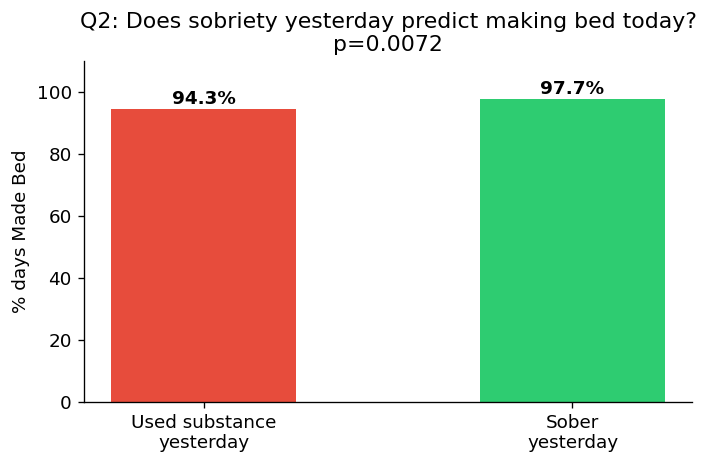

In [59]:
# ── Q2: Does being sober yesterday predict making your bed today? ──────────────
# "Sober" = no Alcohol AND no Weed the day before
lag_df['Sober_lag1'] = ((lag_df['Alcohol_lag1'] == 0) & (lag_df['Weed_lag1'] == 0)).astype(float)
lag_df.loc[lag_df['Alcohol_lag1'].isna() | lag_df['Weed_lag1'].isna(), 'Sober_lag1'] = np.nan

sub = lag_df.dropna(subset=['Sober_lag1', 'Made_Bed'])
sober_bed = sub.groupby('Sober_lag1')['Made_Bed'].agg(['mean', 'count'])
sober_bed.index = ['Used substance yesterday', 'Sober yesterday']
sober_bed.columns = ['Made_Bed_rate', 'N']
sober_bed['Made_Bed_pct'] = (sober_bed['Made_Bed_rate'] * 100).round(1)

print('\nMade Bed rate by sobriety the day before:')
print(sober_bed)

# Chi-squared test for independence
contingency = pd.crosstab(sub['Sober_lag1'], sub['Made_Bed'])
chi2, p_chi, dof, expected = stats.chi2_contingency(contingency)
print(f'\nChi-squared test: χ²={chi2:.2f}, p={p_chi:.4f} (df={dof})')
if p_chi < 0.05:
    print('→ Statistically significant: sobriety yesterday is associated with making the bed today.')
else:
    print('→ Not statistically significant at α=0.05.')

# Visualize
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Used substance\nyesterday', 'Sober\nyesterday'],
              sober_bed['Made_Bed_pct'],
              color=['#e74c3c', '#2ecc71'], width=0.5, edgecolor='none')
for bar, pct in zip(bars, sober_bed['Made_Bed_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{pct:.1f}%', ha='center', va='bottom', fontweight='bold')
ax.set_ylabel('% days Made Bed')
ax.set_title(f'Q2: Does sobriety yesterday predict making bed today?\np={p_chi:.4f}')
ax.set_ylim(0, 110)
plt.tight_layout()
plt.show()

---
# 5. Multiple Regression — Econometrics-Grade Model

Three upgrades over a naive OLS to make this defensible as a time-series model:

1. **Lagged dependent variable (`MH_lag1`)**: Yesterday's mental health is the single strongest predictor of today's. Without it, habit coefficients absorb the autoregressive component and are overstated.
2. **HAC (Newey-West) standard errors**: Daily mood data has autocorrelated and heteroscedastic residuals. HAC corrects standard errors without changing coefficients — p-values become more conservative.
3. **Durbin-Watson test**: Confirms whether residual autocorrelation remains after adding `MH_lag1`. Target: near 2.0.

**Reading the output:** A habit coefficient of +0.3 means — holding all other habits AND yesterday's mood constant — this habit is associated with a 0.3-point higher Mental Health score today.

In [60]:
reg_df = df_int.dropna(subset=[OUTCOME]).copy().sort_values('Date')

# Drop habits with fewer than 20 observed days (too sparse to estimate reliably)
sufficient_habits = [h for h in HABIT_COLS if reg_df[h].sum() >= 20]

# ── Lagged dependent variable ─────────────────────────────────────────────────
# Shift MH by 1 day; null out the lag wherever there is a day gap in tracking
# so we don't carry mood over a break in the series.
reg_df['MH_lag1'] = reg_df[OUTCOME].shift(1)
gap = (reg_df['Date'] - reg_df['Date'].shift(1)).dt.days
reg_df.loc[gap != 1, 'MH_lag1'] = np.nan

predictors = sufficient_habits + ['MH_lag1']
clean_df   = reg_df.dropna(subset=predictors + [OUTCOME])

X = sm.add_constant(clean_df[predictors])
y = clean_df[OUTCOME]

# ── HAC (Newey-West) standard errors ──────────────────────────────────────────
# Corrects for autocorrelation and heteroscedasticity in time-series residuals.
# maxlags=1 is appropriate at daily frequency; increase if DW stat remains far from 2.
model = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 1})
print(model.summary())

# ── Durbin-Watson ─────────────────────────────────────────────────────────────
dw = sm.stats.durbin_watson(model.resid)
print(f'\nDurbin-Watson statistic: {dw:.3f}')
if dw < 1.5:
    print('  → Positive autocorrelation remains. Consider adding MH_lag2 or more lags.')
elif dw > 2.5:
    print('  → Negative autocorrelation. Unusual for mood data — check for over-differencing.')
else:
    print('  → Near 2.0: residual autocorrelation is acceptably low.')

                            OLS Regression Results                            
Dep. Variable:          Mental_Health   R-squared:                       0.190
Model:                            OLS   Adj. R-squared:                  0.179
Method:                 Least Squares   F-statistic:                     17.03
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           1.13e-40
Time:                        21:21:59   Log-Likelihood:                -1826.2
No. Observations:                1098   AIC:                             3684.
Df Residuals:                    1082   BIC:                             3764.
Df Model:                          15                                         
Covariance Type:                  HAC                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             3.3741      0.268     12.597

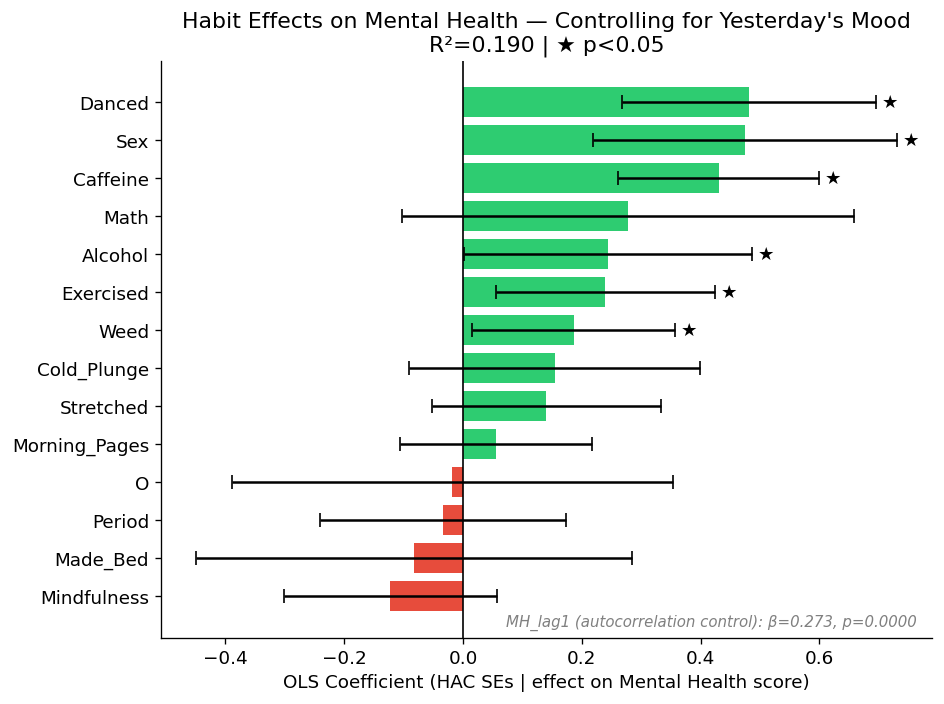

Model R² = 0.190 (19.0% of variance explained)
Adjusted R² = 0.179


In [61]:
# ── Coefficient plot — habit predictors only (MH_lag1 shown separately) ───────
# MH_lag1 is a control variable, not a habit; exclude it from the habit chart
# so the scale isn't dominated by the autoregressive term.
coef    = model.params.drop(['const', 'MH_lag1'])
conf    = model.conf_int().drop(['const', 'MH_lag1'])
p_vals  = model.pvalues.drop(['const', 'MH_lag1'])

coef_df = pd.DataFrame({
    'Habit':   coef.index,
    'Coef':    coef.values,
    'CI_low':  conf[0].values,
    'CI_high': conf[1].values,
    'p':       p_vals.values,
}).sort_values('Coef')

fig, ax = plt.subplots(figsize=(8, 6))
colors_coef = ['#e74c3c' if c < 0 else '#2ecc71' for c in coef_df['Coef']]
ax.barh(coef_df['Habit'], coef_df['Coef'],
        xerr=[coef_df['Coef'] - coef_df['CI_low'],
              coef_df['CI_high'] - coef_df['Coef']],
        color=colors_coef, capsize=4, edgecolor='none')
ax.axvline(0, color='black', linewidth=1)

for _, row in coef_df.iterrows():
    if row['p'] < 0.05:
        y_pos = list(coef_df['Habit']).index(row['Habit'])
        ax.text(row['CI_high'] + 0.01, y_pos, '★', va='center', fontsize=11)

# Annotate MH_lag1 coefficient separately
mh_lag_coef = model.params.get('MH_lag1', None)
mh_lag_p    = model.pvalues.get('MH_lag1', None)
if mh_lag_coef is not None:
    ax.text(0.98, 0.02,
            f'MH_lag1 (autocorrelation control): β={mh_lag_coef:.3f}, p={mh_lag_p:.4f}',
            transform=ax.transAxes, ha='right', fontsize=9, color='grey',
            style='italic')

ax.set_xlabel('OLS Coefficient (HAC SEs | effect on Mental Health score)')
ax.set_title(f'Habit Effects on Mental Health — Controlling for Yesterday\'s Mood\nR²={model.rsquared:.3f} | ★ p<0.05')
plt.tight_layout()
plt.show()

print(f'Model R² = {model.rsquared:.3f} ({model.rsquared*100:.1f}% of variance explained)')
print(f'Adjusted R² = {model.rsquared_adj:.3f}')

---
# 5a. Stationarity Check — Augmented Dickey-Fuller Test

OLS on time-series data can produce spuriously high R² values if both the outcome and
predictors share a long-run trend (unit root). The ADF test checks for this.

- **H₀**: Mental_Health has a unit root (non-stationary — trends up or down indefinitely)
- **H₁**: Mental_Health is stationary (mean-reverting)

If p < 0.05 we reject H₀ and conclude the series is stationary — OLS results are not spurious.
If p > 0.05, consider first-differencing the outcome before regression.

Augmented Dickey-Fuller Test — Mental_Health stationarity
  ADF statistic : -10.9557
  p-value       : 0.0000
  Lags selected : 5
  Critical values:
    1%: -3.4357
    5%: -2.8639
    10%: -2.5680

→ Stationary (p < 0.05). No unit root detected.
  OLS results are not spurious due to a shared long-run trend.


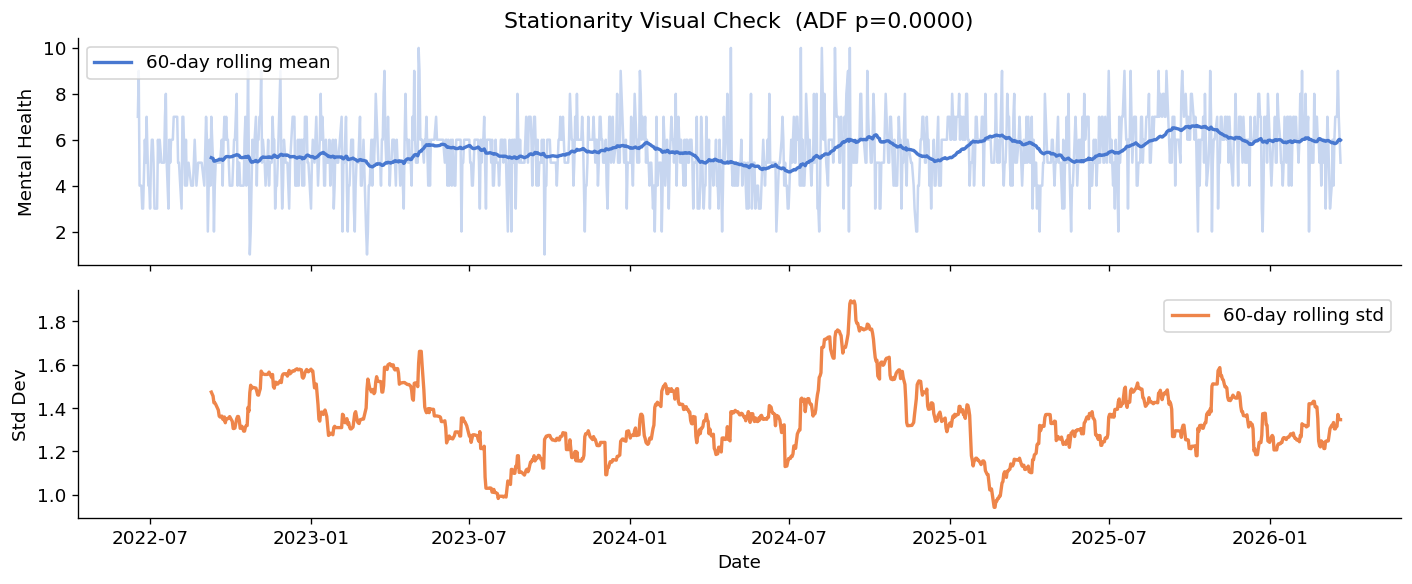

In [62]:
from statsmodels.tsa.stattools import adfuller

mh_series = (df_int[['Date', OUTCOME]]
             .dropna()
             .sort_values('Date')
             .set_index('Date')[OUTCOME])

adf_stat, adf_p, adf_lags, _, adf_crit, _ = adfuller(mh_series, autolag='AIC')

print('Augmented Dickey-Fuller Test — Mental_Health stationarity')
print(f'  ADF statistic : {adf_stat:.4f}')
print(f'  p-value       : {adf_p:.4f}')
print(f'  Lags selected : {adf_lags}')
print('  Critical values:')
for key, val in adf_crit.items():
    print(f'    {key}: {val:.4f}')

print()
if adf_p < 0.05:
    print('→ Stationary (p < 0.05). No unit root detected.')
    print('  OLS results are not spurious due to a shared long-run trend.')
else:
    print('→ Possible unit root (p > 0.05). Consider first-differencing:')
    print('  df_int["MH_diff"] = df_int[OUTCOME].diff()')
    print('  and re-running regression on the differenced outcome.')

# Visual check: rolling mean and variance (should be flat if stationary)
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
roll_mean = mh_series.rolling(60).mean()
roll_std  = mh_series.rolling(60).std()

axes[0].plot(mh_series, alpha=0.3, color=PALETTE[0])
axes[0].plot(roll_mean, color=PALETTE[0], linewidth=2, label='60-day rolling mean')
axes[0].set_ylabel('Mental Health')
axes[0].set_title(f'Stationarity Visual Check  (ADF p={adf_p:.4f})')
axes[0].legend()

axes[1].plot(roll_std, color=PALETTE[1], linewidth=2, label='60-day rolling std')
axes[1].set_ylabel('Std Dev')
axes[1].set_xlabel('Date')
axes[1].legend()

plt.tight_layout()
plt.show()

---
# 5b. Reverse Causality / Endogeneity Check

The review flagged a key threat: **simultaneity**. Does low mood *cause* drinking,
rather than (or in addition to) drinking causing low mood?

We test this by asking: *does yesterday's Mental_Health predict today's substance use?*  
If people with lower mood yesterday use more substances today, substance use is **endogenous** —
it is both a cause *and* an effect of mood, and the OLS coefficient is biased.

This is a necessary sanity check; it cannot fully resolve endogeneity without an
instrumental variable, but it tells us whether the concern is empirically relevant.

Reverse Causality Check
Does LOWER Mental_Health yesterday predict MORE substance use today?
(If yes → endogeneity: mood is both a cause and effect of substance use)

Alcohol:
  MH yesterday on days used today    : 5.42 (n=149)
  MH yesterday on days NOT used today: 5.54 (n=951)
  Difference: -0.12  |  Mann-Whitney p=0.2865
  No significant reverse causality detected (p=0.2865).

Weed:
  MH yesterday on days used today    : 5.63 (n=435)
  MH yesterday on days NOT used today: 5.46 (n=665)
  Difference: +0.18  |  Mann-Whitney p=0.0539
  No significant reverse causality detected (p=0.0539).



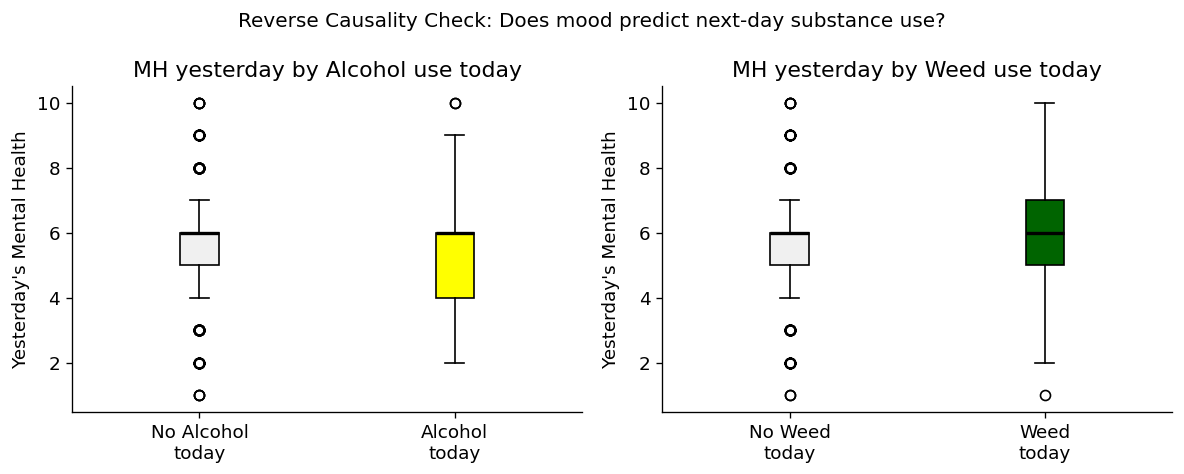

In [63]:
# Build a version of df_int with yesterday's MH as a predictor
endo_df = df_int.sort_values('Date').copy()
endo_df['MH_lag1'] = endo_df[OUTCOME].shift(1)
# Null out lags that cross a tracking gap
gap = (endo_df['Date'] - endo_df['Date'].shift(1)).dt.days
endo_df.loc[gap != 1, 'MH_lag1'] = np.nan
endo_df = endo_df.dropna(subset=['MH_lag1'])

print('Reverse Causality Check')
print('Does LOWER Mental_Health yesterday predict MORE substance use today?')
print('(If yes → endogeneity: mood is both a cause and effect of substance use)\n')

substances = [s for s in ['Alcohol', 'Weed'] if s in HABIT_COLS]
for substance in substances:
    sub = endo_df.dropna(subset=[substance, 'MH_lag1'])
    if sub[substance].sum() < 10:
        print(f'{substance}: insufficient use days (n={sub[substance].sum()})\n')
        continue

    used     = sub.loc[sub[substance] == 1, 'MH_lag1']
    not_used = sub.loc[sub[substance] == 0, 'MH_lag1']
    _, p_mw  = stats.mannwhitneyu(used, not_used, alternative='two-sided')
    diff     = used.mean() - not_used.mean()

    print(f'{substance}:')
    print(f'  MH yesterday on days used today    : {used.mean():.2f} (n={len(used)})')
    print(f'  MH yesterday on days NOT used today: {not_used.mean():.2f} (n={len(not_used)})')
    print(f'  Difference: {diff:+.2f}  |  Mann-Whitney p={p_mw:.4f}')

    if p_mw < 0.05 and diff < 0:
        print(f'  ⚠ Significant: lower mood yesterday predicts MORE {substance} today.')
        print(f'    → Reverse causality is empirically relevant. The OLS coefficient for')
        print(f'      {substance} likely overestimates its negative causal effect on mood.')
    elif p_mw < 0.05 and diff > 0:
        print(f'  ↑ Significant: higher mood yesterday predicts MORE {substance} today.')
        print(f'    → Suggests use is recreational (good days) rather than coping.')
    else:
        print(f'  No significant reverse causality detected (p={p_mw:.4f}).')
    print()

# Visual: distribution of MH_lag1 by substance use
fig, axes = plt.subplots(1, len(substances), figsize=(5 * len(substances), 4))
if len(substances) == 1:
    axes = [axes]
for ax, substance in zip(axes, substances):
    sub = endo_df.dropna(subset=[substance, 'MH_lag1'])
    groups = [sub.loc[sub[substance] == 0, 'MH_lag1'],
              sub.loc[sub[substance] == 1, 'MH_lag1']]
    bp = ax.boxplot(groups, labels=[f'No {substance}\ntoday', f'{substance}\ntoday'],
                    patch_artist=True, medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor('#f0f0f0')
    bp['boxes'][1].set_facecolor(config.VAR_COLORS.get(substance, 'steelblue'))
    ax.set_title(f'MH yesterday by {substance} use today')
    ax.set_ylabel("Yesterday's Mental Health")
    ax.set_ylim(0.5, 10.5)
fig.suptitle('Reverse Causality Check: Does mood predict next-day substance use?',
             fontsize=12)
plt.tight_layout()
plt.show()

---
# 6. Habit–Habit Correlations

Explore which habits tend to occur together.  
**Expected:** Exercised and Stretched should be highly correlated (you stretch after exercising).  
**Method:** Pearson correlation on 0/1 encoded booleans (equivalent to phi coefficient for binary–binary pairs).

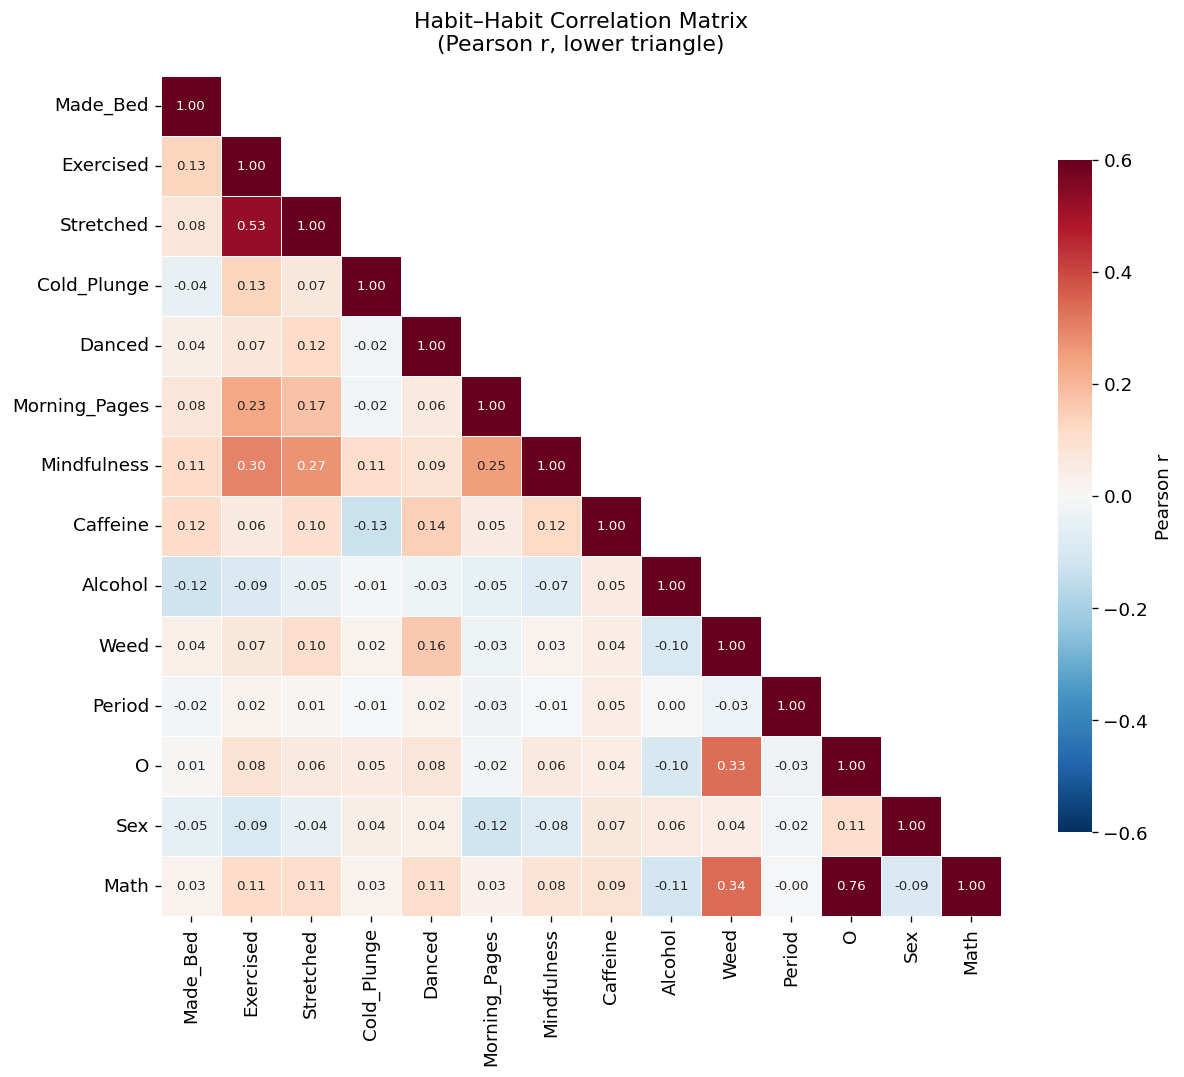


Notable correlations (|r| > 0.2):
  Made_Bed        ↔ Made_Bed         r=1.000
  Exercised       ↔ Exercised        r=1.000
  Stretched       ↔ Exercised        r=0.526
  Morning_Pages   ↔ Exercised        r=0.230
  Mindfulness     ↔ Exercised        r=0.298
  Stretched       ↔ Stretched        r=1.000
  Mindfulness     ↔ Stretched        r=0.269
  Cold_Plunge     ↔ Cold_Plunge      r=1.000
  Danced          ↔ Danced           r=1.000
  Morning_Pages   ↔ Morning_Pages    r=1.000
  Mindfulness     ↔ Morning_Pages    r=0.252
  Mindfulness     ↔ Mindfulness      r=1.000
  Caffeine        ↔ Caffeine         r=1.000
  Alcohol         ↔ Alcohol          r=1.000
  Weed            ↔ Weed             r=1.000
  O               ↔ Weed             r=0.333
  Math            ↔ Weed             r=0.339
  Period          ↔ Period           r=1.000
  O               ↔ O                r=1.000
  Math            ↔ O                r=0.762
  Sex             ↔ Sex              r=1.000
  Math            ↔ 

In [64]:
# ── Correlation matrix ─────────────────────────────────────────────────────────
corr_df = df_int[HABIT_COLS].dropna(how='all')
corr_matrix = corr_df.corr(method='pearson')

# Compute p-values for each pair
n = len(corr_df)
p_matrix = pd.DataFrame(np.ones_like(corr_matrix), index=corr_matrix.index, columns=corr_matrix.columns)
for col1 in HABIT_COLS:
    for col2 in HABIT_COLS:
        if col1 != col2:
            pair = corr_df[[col1, col2]].dropna()
            if len(pair) > 2:
                _, p = stats.pearsonr(pair[col1], pair[col2])
                p_matrix.loc[col1, col2] = p

# Mask upper triangle for cleaner display
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr_matrix, mask=mask, ax=ax,
    cmap='RdBu_r', center=0, vmin=-0.6, vmax=0.6,
    square=True, annot=True, fmt='.2f', annot_kws={'size': 8},
    linewidths=0.5, linecolor='white',
    cbar_kws={'shrink': 0.8, 'label': 'Pearson r'},
)
ax.set_title('Habit–Habit Correlation Matrix\n(Pearson r, lower triangle)', pad=15)
plt.tight_layout()
plt.show()

# Print notable strong correlations (|r| > 0.2)
print('\nNotable correlations (|r| > 0.2):')
upper_tri = corr_matrix.where(~mask)
for col in upper_tri.columns:
    for row in upper_tri.index:
        val = upper_tri.loc[row, col]
        if not np.isnan(val) and abs(val) > 0.2:
            print(f'  {row:15s} ↔ {col:15s}  r={val:.3f}')

---
# 7. Seasonal Analysis

Do habits and mental health vary by season?  
- Do I cold plunge more in winter?
- Do I experience seasonal depression (lower MH in winter/fall)?
- Which season do I exercise most?

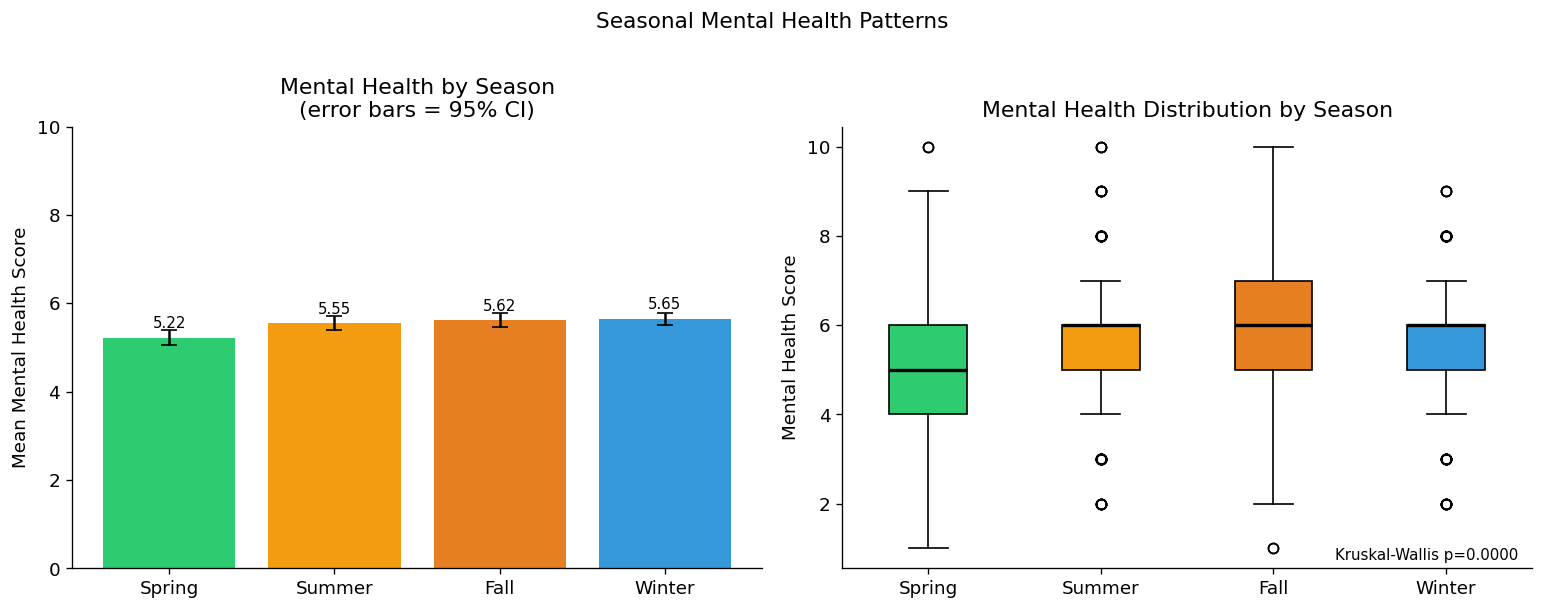


Kruskal-Wallis: H=23.02, p=0.0000
        mean  count
Season             
Spring  5.22    276
Summer  5.55    312
Fall    5.62    312
Winter  5.65    327


In [65]:
# ── Mental health by season ────────────────────────────────────────────────────
season_order = ['Spring', 'Summer', 'Fall', 'Winter']
season_mh = df_int.groupby('Season')[OUTCOME].agg(['mean', 'std', 'count'])
season_mh = season_mh.reindex(season_order)
season_mh['se'] = season_mh['std'] / np.sqrt(season_mh['count'])

season_colors = {'Spring': '#2ecc71', 'Summer': '#f39c12', 'Fall': '#e67e22', 'Winter': '#3498db'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart: mean MH by season
bars = axes[0].bar(
    season_mh.index, season_mh['mean'],
    yerr=season_mh['se'] * 1.96, capsize=5,
    color=[season_colors[s] for s in season_mh.index],
    edgecolor='none'
)
axes[0].set_ylabel('Mean Mental Health Score')
axes[0].set_title('Mental Health by Season\n(error bars = 95% CI)')
axes[0].set_ylim(0, 10)
for bar, (_, row) in zip(bars, season_mh.iterrows()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
                 f'{row["mean"]:.2f}', ha='center', va='bottom', fontsize=9)

# Box plot
season_groups = [df_int.loc[df_int['Season'] == s, OUTCOME].dropna() for s in season_order]
bp = axes[1].boxplot(season_groups, labels=season_order, patch_artist=True,
                     medianprops=dict(color='black', linewidth=2))
for patch, season in zip(bp['boxes'], season_order):
    patch.set_facecolor(season_colors[season])
axes[1].set_ylabel('Mental Health Score')
axes[1].set_title('Mental Health Distribution by Season')

# Kruskal-Wallis test (non-parametric ANOVA)
kw_stat, kw_p = stats.kruskal(*season_groups)
axes[1].text(0.98, 0.02, f'Kruskal-Wallis p={kw_p:.4f}',
             transform=axes[1].transAxes, ha='right', fontsize=9)

plt.suptitle('Seasonal Mental Health Patterns', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print(f'\nKruskal-Wallis: H={kw_stat:.2f}, p={kw_p:.4f}')
print(season_mh[['mean', 'count']].round(2))

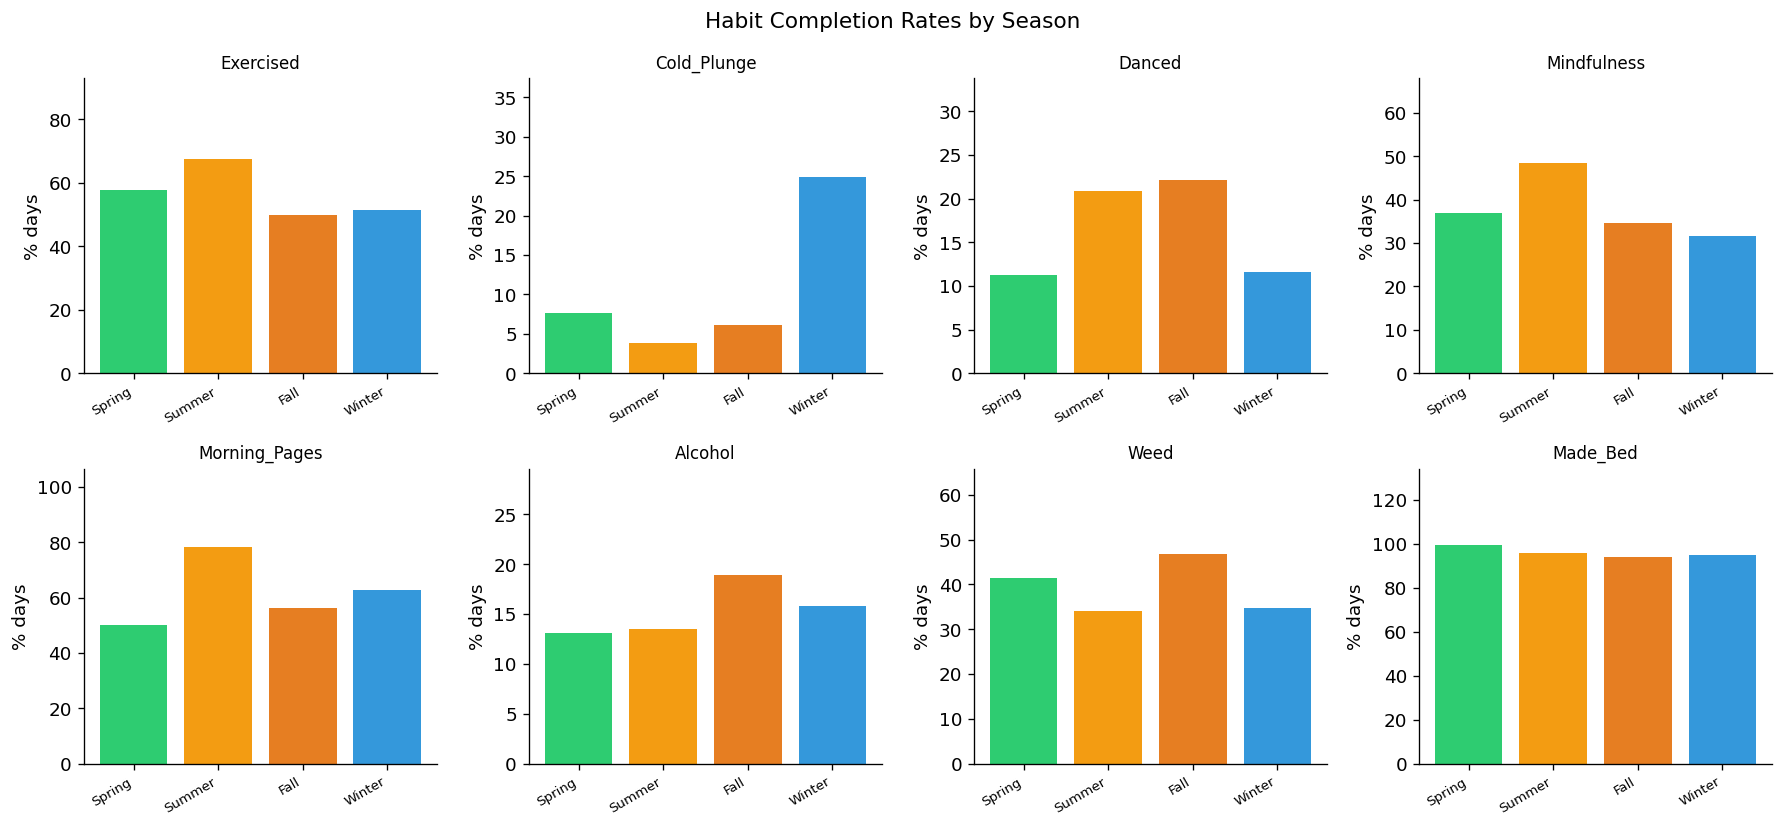

In [66]:
# ── Habit rates by season ──────────────────────────────────────────────────────
habits_to_plot = ['Exercised', 'Cold_Plunge', 'Danced', 'Mindfulness',
                  'Morning_Pages', 'Alcohol', 'Weed', 'Made_Bed']

seasonal_habits = df_int.groupby('Season')[habits_to_plot].mean() * 100
seasonal_habits = seasonal_habits.reindex(season_order)

fig, axes = plt.subplots(2, 4, figsize=(15, 7), sharey=False)
axes = axes.flatten()

for ax, habit in zip(axes, habits_to_plot):
    vals = seasonal_habits[habit]
    ax.bar(vals.index, vals.values,
           color=[season_colors[s] for s in vals.index], edgecolor='none')
    ax.set_title(habit, fontsize=10)
    ax.set_ylabel('% days')
    ax.set_xticklabels(vals.index, rotation=30, ha='right', fontsize=8)
    ax.set_ylim(0, max(vals.values) * 1.3 + 5)

fig.suptitle('Habit Completion Rates by Season', fontsize=13)
plt.tight_layout()
plt.show()

---
# 8. Year-over-Year Comparison

How have my habits and mental health evolved over the tracking years?  
Each subplot shows one year, making it easy to spot multi-year trends.

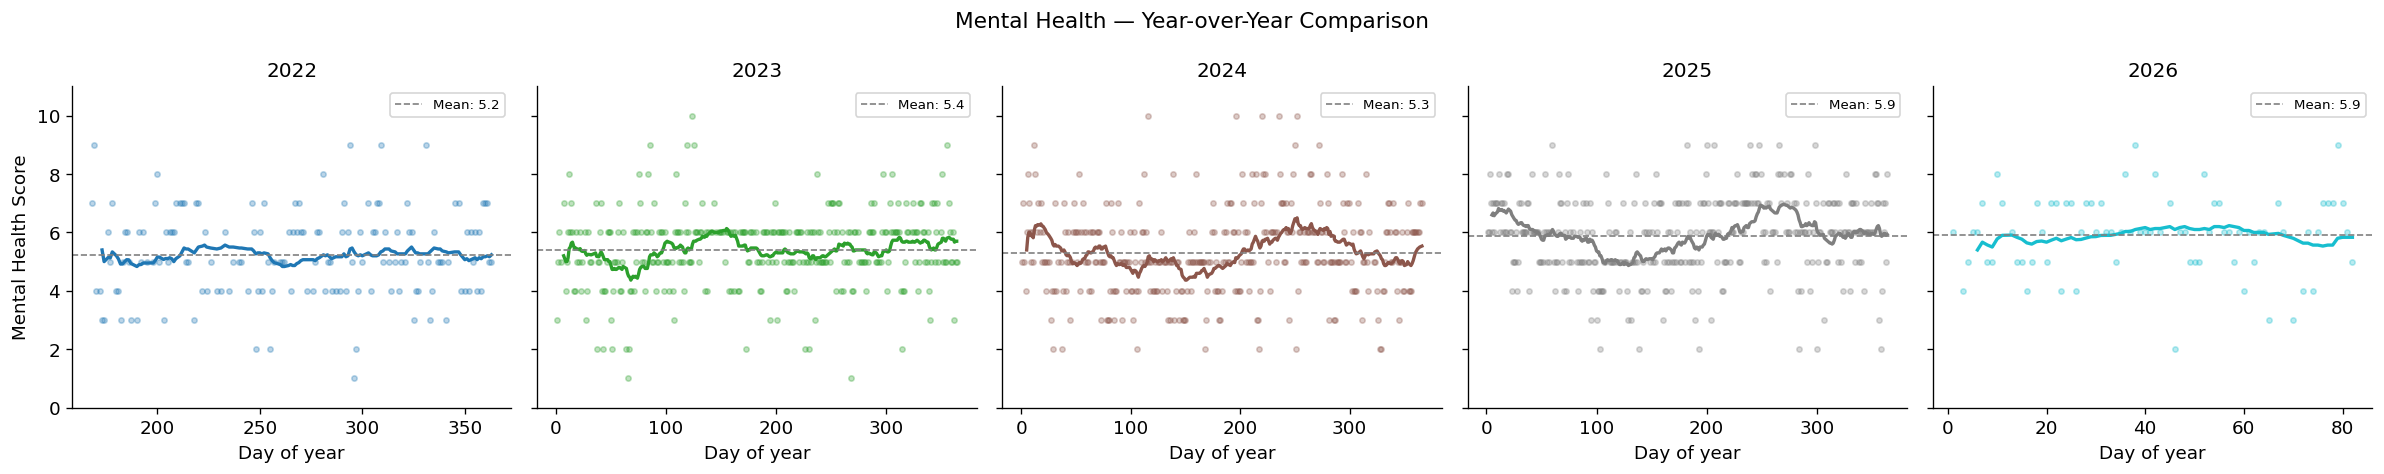

In [67]:
# ── Mental health: year-over-year comparison ───────────────────────────────────
years = sorted(df_int['Year'].unique())
n_years = len(years)

fig, axes = plt.subplots(1, n_years, figsize=(4 * n_years, 4), sharey=True)
if n_years == 1:
    axes = [axes]

year_palette = plt.cm.tab10(np.linspace(0, 1, n_years))

for ax, year, color in zip(axes, years, year_palette):
    yr_data = df_int[df_int['Year'] == year][['Date', OUTCOME]].dropna()
    yr_data = yr_data.sort_values('Date')

    # Day-of-year for x-axis so all years share the same 1–365 scale
    yr_data['DayOfYear'] = yr_data['Date'].dt.dayofyear

    ax.scatter(yr_data['DayOfYear'], yr_data[OUTCOME],
               alpha=0.3, color=color, s=10)
    roll = yr_data.set_index('DayOfYear')[OUTCOME].rolling(30, min_periods=5).mean()
    ax.plot(roll.index, roll.values, color=color, linewidth=2)

    ax.set_title(str(year), fontsize=12)
    ax.set_xlabel('Day of year')
    ax.set_ylim(0, 11)
    ax.axhline(yr_data[OUTCOME].mean(), linestyle='--', color='grey', linewidth=1,
               label=f'Mean: {yr_data[OUTCOME].mean():.1f}')
    ax.legend(fontsize=8)

axes[0].set_ylabel('Mental Health Score')
fig.suptitle('Mental Health \u2014 Year-over-Year Comparison', fontsize=13)
plt.tight_layout()
plt.show()

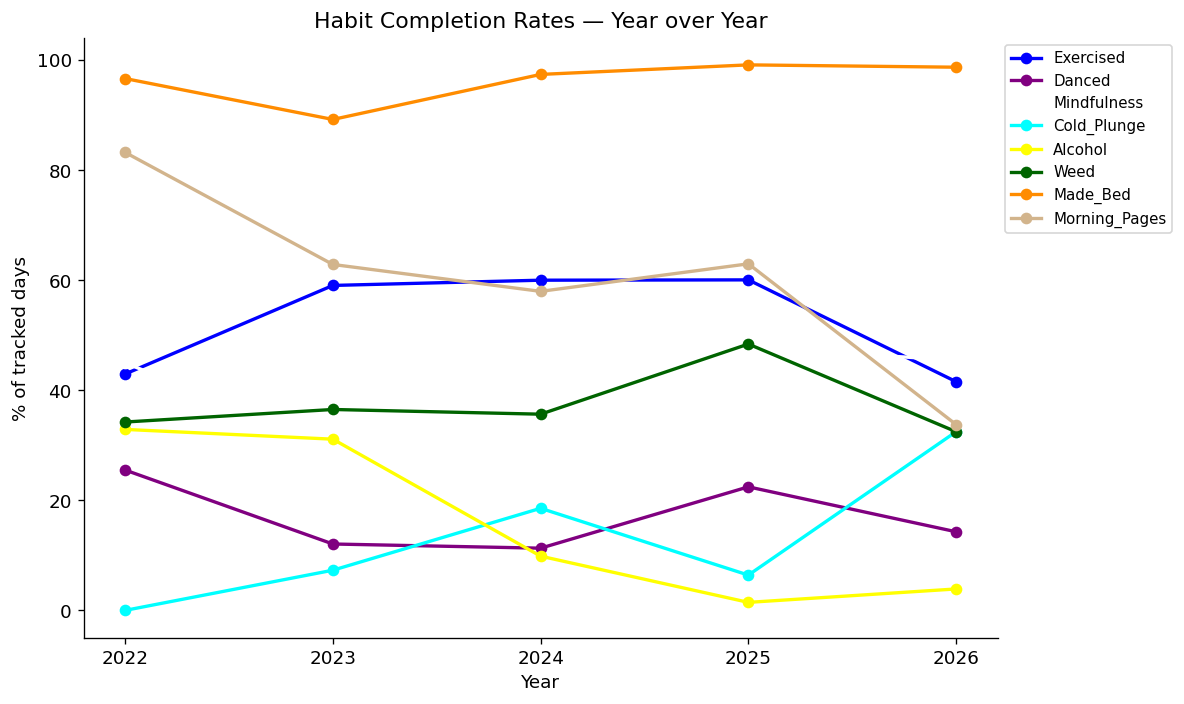

In [68]:
# ── Habit completion rates: year over year ─────────────────────────────────────
highlight_habits = ['Exercised', 'Danced', 'Mindfulness', 'Cold_Plunge',
                    'Alcohol', 'Weed', 'Made_Bed', 'Morning_Pages']

yoy_habits = df_int.groupby('Year')[highlight_habits].mean() * 100

fig, ax = plt.subplots(figsize=(10, 6))
for i, habit in enumerate(highlight_habits):
    color = config.VAR_COLORS.get(habit, PALETTE[i % len(PALETTE)])
    ax.plot(yoy_habits.index, yoy_habits[habit],
            marker='o', label=habit, color=color, linewidth=2)

ax.set_xlabel('Year')
ax.set_ylabel('% of tracked days')
ax.set_title('Habit Completion Rates — Year over Year')
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=9)
ax.set_xticks(yoy_habits.index)
plt.tight_layout()
plt.show()

---
# 9. Direct Answers to Key Questions

Summarizing the evidence for each specific question with both effect size and statistical significance.

Q1: DOES EXERCISE MAKE ME FEEL BETTER?

[Same day]
  Exercise days    — mean MH: 5.67 (n=695)
  No exercise days — mean MH: 5.33 (n=532)
  Difference: +0.33
  Point-biserial r=0.115, Mann-Whitney p=0.0000

[Next day (lagged effect)]
  After exercise    — mean MH: 5.62
  After no exercise — mean MH: 5.44
  Difference: +0.17
  Mann-Whitney p=0.1716


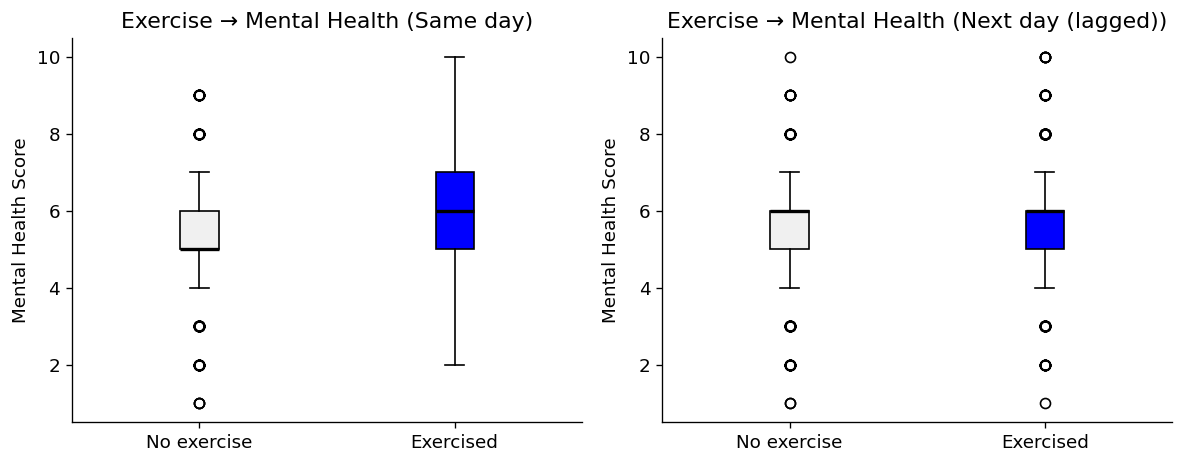

In [69]:
# ══════════════════════════════════════════════════════════════════════════════
# Q1: Does exercise make me feel better?
# Same-day AND next-day effects
# ══════════════════════════════════════════════════════════════════════════════

print('=' * 60)
print('Q1: DOES EXERCISE MAKE ME FEEL BETTER?')
print('=' * 60)

# Same-day
ex_same = analysis_df.copy()
ex_done = ex_same.loc[ex_same['Exercised'] == 1, OUTCOME]
ex_not  = ex_same.loc[ex_same['Exercised'] == 0, OUTCOME]
r_same, p_same = stats.pointbiserialr(ex_same['Exercised'], ex_same[OUTCOME])
_, p_mw_same = stats.mannwhitneyu(ex_done, ex_not, alternative='two-sided')

print(f'\n[Same day]')
print(f'  Exercise days    — mean MH: {ex_done.mean():.2f} (n={len(ex_done)})')
print(f'  No exercise days — mean MH: {ex_not.mean():.2f} (n={len(ex_not)})')
print(f'  Difference: {ex_done.mean() - ex_not.mean():+.2f}')
print(f'  Point-biserial r={r_same:.3f}, Mann-Whitney p={p_mw_same:.4f}')

# Next-day
lag_ex = lag_df.dropna(subset=[OUTCOME, 'Exercised_lag1'])
ex_done_lag = lag_ex.loc[lag_ex['Exercised_lag1'] == 1, OUTCOME]
ex_not_lag  = lag_ex.loc[lag_ex['Exercised_lag1'] == 0, OUTCOME]
_, p_mw_lag = stats.mannwhitneyu(ex_done_lag, ex_not_lag, alternative='two-sided')

print(f'\n[Next day (lagged effect)]')
print(f'  After exercise    — mean MH: {ex_done_lag.mean():.2f}')
print(f'  After no exercise — mean MH: {ex_not_lag.mean():.2f}')
print(f'  Difference: {ex_done_lag.mean() - ex_not_lag.mean():+.2f}')
print(f'  Mann-Whitney p={p_mw_lag:.4f}')

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (done_grp, not_grp, title) in zip(axes, [
    (ex_done, ex_not, 'Same day'),
    (ex_done_lag, ex_not_lag, 'Next day (lagged)'),
]):
    bp = ax.boxplot([not_grp, done_grp], labels=['No exercise', 'Exercised'],
                    patch_artist=True, medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor('#f0f0f0')
    bp['boxes'][1].set_facecolor(config.VAR_COLORS.get('Exercised', 'blue'))
    ax.set_title(f'Exercise → Mental Health ({title})')
    ax.set_ylabel('Mental Health Score')
    ax.set_ylim(0.5, 10.5)

plt.tight_layout()
plt.show()

In [70]:
# ══════════════════════════════════════════════════════════════════════════════
# Q3: Does dancing make me happier?
# ══════════════════════════════════════════════════════════════════════════════

print('=' * 60)
print('Q3: DOES DANCING MAKE ME HAPPIER?')
print('=' * 60)

dance_df = analysis_df.copy()
danced    = dance_df.loc[dance_df['Danced'] == 1, OUTCOME]
not_dance = dance_df.loc[dance_df['Danced'] == 0, OUTCOME]

r_d, p_r_d = stats.pointbiserialr(dance_df['Danced'], dance_df[OUTCOME])
_, p_mw_d = stats.mannwhitneyu(danced, not_dance, alternative='two-sided')

print(f'\n  Dance days    — mean MH: {danced.mean():.2f} (n={len(danced)})')
print(f'  No dance days — mean MH: {not_dance.mean():.2f} (n={len(not_dance)})')
print(f'  Difference: {danced.mean() - not_dance.mean():+.2f}')
print(f'  Point-biserial r={r_d:.3f}, Mann-Whitney p={p_mw_d:.4f}')
sig = 'YES (statistically significant)' if p_mw_d < 0.05 else 'NOT statistically significant'
print(f'\n  Answer: {sig}')

# Also: does dancing on day T predict higher MH on day T+1?
lag_dance = lag_df.dropna(subset=[OUTCOME, 'Danced_lag1'])
d_yes = lag_dance.loc[lag_dance['Danced_lag1'] == 1, OUTCOME]
d_no  = lag_dance.loc[lag_dance['Danced_lag1'] == 0, OUTCOME]
_, p_lag_d = stats.mannwhitneyu(d_yes, d_no, alternative='two-sided')
print(f'\n  Lagged (danced yesterday → today MH): {d_yes.mean():.2f} vs {d_no.mean():.2f}, p={p_lag_d:.4f}')

Q3: DOES DANCING MAKE ME HAPPIER?

  Dance days    — mean MH: 6.13 (n=203)
  No dance days — mean MH: 5.40 (n=1024)
  Difference: +0.73
  Point-biserial r=0.191, Mann-Whitney p=0.0000

  Answer: YES (statistically significant)

  Lagged (danced yesterday → today MH): 5.80 vs 5.49, p=0.0119


Q4: DO DRUGS NEGATIVELY IMPACT MENTAL HEALTH?

── Alcohol ──
  Use days     — mean MH: 5.65 (n=188)
  No-use days  — mean MH: 5.50 (n=1039)
  Difference: +0.16
  Same-day: r=0.039, p=0.4174 
  Next-day: 5.22 vs 5.60, p=0.0026 ← significant

── Weed ──
  Use days     — mean MH: 5.77 (n=479)
  No-use days  — mean MH: 5.37 (n=748)
  Difference: +0.40
  Same-day: r=0.137, p=0.0000 ← significant
  Next-day: 5.55 vs 5.54, p=0.5174 


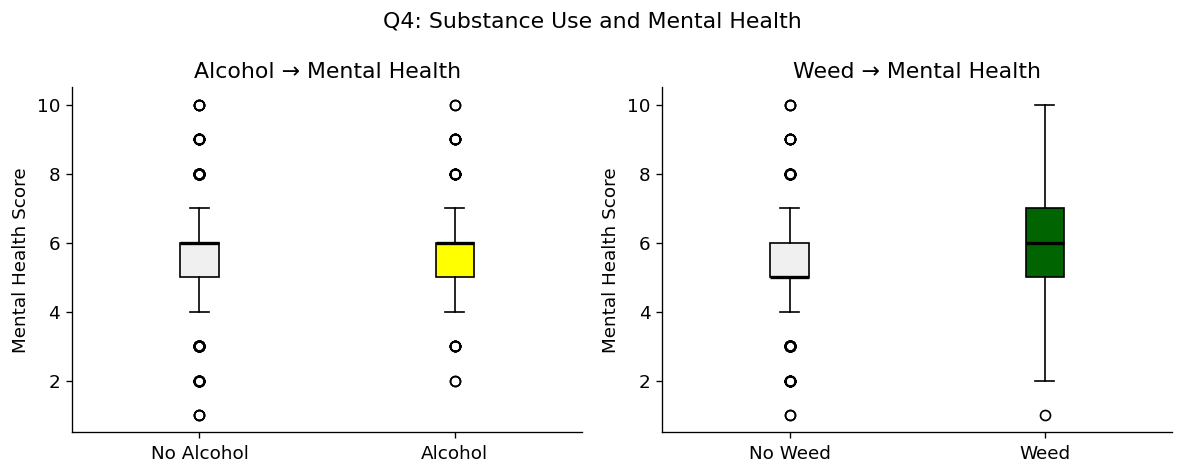

In [71]:
# ══════════════════════════════════════════════════════════════════════════════
# Q4: Do drugs have a negative impact on mental health?
# Test Alcohol and Weed — same-day and next-day
# ══════════════════════════════════════════════════════════════════════════════

print('=' * 60)
print('Q4: DO DRUGS NEGATIVELY IMPACT MENTAL HEALTH?')
print('=' * 60)

for substance in ['Alcohol', 'Weed']:
    sub_df = analysis_df.copy()
    yes_grp = sub_df.loc[sub_df[substance] == 1, OUTCOME]
    no_grp  = sub_df.loc[sub_df[substance] == 0, OUTCOME]

    if len(yes_grp) < 10:
        print(f'\n{substance}: insufficient data (n={len(yes_grp)})')
        continue

    r_sub, _ = stats.pointbiserialr(sub_df[substance], sub_df[OUTCOME])
    _, p_mw_sub = stats.mannwhitneyu(yes_grp, no_grp, alternative='two-sided')

    # Lagged (yesterday's use → today's MH)
    lag_sub = lag_df.dropna(subset=[OUTCOME, f'{substance}_lag1'])
    lag_yes = lag_sub.loc[lag_sub[f'{substance}_lag1'] == 1, OUTCOME]
    lag_no  = lag_sub.loc[lag_sub[f'{substance}_lag1'] == 0, OUTCOME]
    _, p_lag_sub = stats.mannwhitneyu(lag_yes, lag_no, alternative='two-sided') if len(lag_yes) >= 10 else (None, None)

    print(f'\n── {substance} ──')
    print(f'  Use days     — mean MH: {yes_grp.mean():.2f} (n={len(yes_grp)})')
    print(f'  No-use days  — mean MH: {no_grp.mean():.2f} (n={len(no_grp)})')
    print(f'  Difference: {yes_grp.mean() - no_grp.mean():+.2f}')
    print(f'  Same-day: r={r_sub:.3f}, p={p_mw_sub:.4f}', '← significant' if p_mw_sub < 0.05 else '')
    if p_lag_sub is not None:
        print(f'  Next-day: {lag_yes.mean():.2f} vs {lag_no.mean():.2f}, p={p_lag_sub:.4f}',
              '← significant' if p_lag_sub < 0.05 else '')

# Visualization: MH distributions for alcohol/weed vs sober
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, substance in zip(axes, ['Alcohol', 'Weed']):
    sub_df = analysis_df.copy()
    yes_grp = sub_df.loc[sub_df[substance] == 1, OUTCOME]
    no_grp  = sub_df.loc[sub_df[substance] == 0, OUTCOME]
    if len(yes_grp) < 5:
        ax.text(0.5, 0.5, 'Insufficient data', ha='center', transform=ax.transAxes)
        continue
    bp = ax.boxplot([no_grp, yes_grp], labels=[f'No {substance}', f'{substance}'],
                    patch_artist=True, medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor('#f0f0f0')
    bp['boxes'][1].set_facecolor(config.VAR_COLORS.get(substance, 'orange'))
    ax.set_title(f'{substance} → Mental Health')
    ax.set_ylabel('Mental Health Score')
    ax.set_ylim(0.5, 10.5)

plt.suptitle('Q4: Substance Use and Mental Health')
plt.tight_layout()
plt.show()

---
# 10. Monthly Habit Heatmap (Seasonal Patterns)

A heatmap where rows = month of year (Jan–Dec) and columns = habit,  
showing the average completion rate aggregated across all years.  
This surfaces seasonal rhythms clearly.

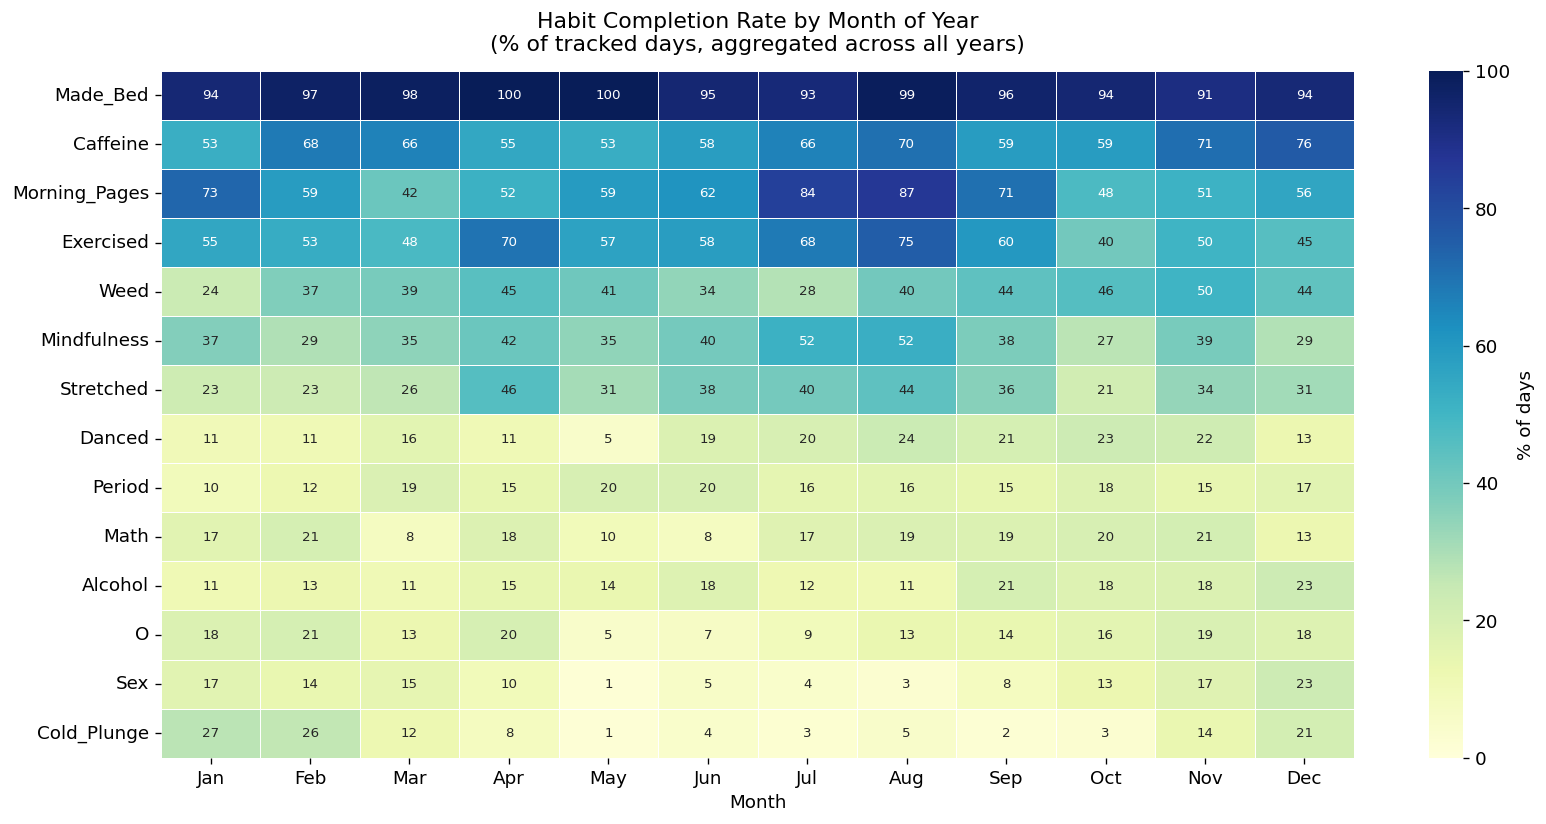

In [72]:
monthly_pivot = df_int.groupby('Month')[HABIT_COLS].mean() * 100
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_pivot.index = [month_labels[m - 1] for m in monthly_pivot.index]

# Reorder habits by overall mean (most common at top)
habit_order = monthly_pivot.mean().sort_values(ascending=False).index.tolist()
monthly_pivot = monthly_pivot[habit_order]

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(
    monthly_pivot.T, ax=ax,
    cmap='YlGnBu', vmin=0, vmax=100,
    annot=True, fmt='.0f', annot_kws={'size': 8},
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': '% of days'},
)
ax.set_xlabel('Month')
ax.set_ylabel('')
ax.set_title('Habit Completion Rate by Month of Year\n(% of tracked days, aggregated across all years)', pad=12)
plt.tight_layout()
plt.show()

---
# 11. Summary of Findings

Run this cell last to print a consolidated summary of all significant results.

In [73]:
print('=' * 70)
print('STATISTICAL ANALYSIS SUMMARY')
print('=' * 70)

print('\n── Habits with significant same-day effect on Mental Health (BH-corrected) ──')
sig_rows = results_df[results_df['sig_BH']].sort_values('MH_diff', ascending=False)
if len(sig_rows) > 0:
    for _, row in sig_rows.iterrows():
        direction = 'POSITIVE' if row['MH_diff'] > 0 else 'NEGATIVE'
        print(f'  {direction:8s} | {row["Habit"]:15s} | Δ={row["MH_diff"]:+.2f} | p_BH={row["p_BH"]:.4f}')
else:
    print('  (none after correction)')

print('\n── Habits with significant lagged effect on Mental Health (BH-corrected) ──')
lag_sig = lag_res_df[lag_res_df['sig_BH']].sort_values('MH_diff', ascending=False)
if len(lag_sig) > 0:
    for _, row in lag_sig.iterrows():
        direction = 'POSITIVE' if row['MH_diff'] > 0 else 'NEGATIVE'
        print(f'  {direction:8s} | {row["Habit (yesterday)"]:15s} | Δ={row["MH_diff"]:+.2f} | p_BH={row["p_BH"]:.4f}')
else:
    print('  (none after correction)')

print('\n── Regression model summary ──')
sig_coef = coef_df[coef_df['p'] < 0.05].sort_values('Coef', ascending=False)
if len(sig_coef) > 0:
    for _, row in sig_coef.iterrows():
        print(f'  {row["Habit"]:15s} | β={row["Coef"]:+.3f} | p={row["p"]:.4f}')
else:
    print('  (no habit significantly predicts MH in the multi-variable model)')
print(f'  Model R² = {model.rsquared:.3f} (explains {model.rsquared*100:.1f}% of variance)')

print('\n── Strongest habit–habit correlations (|r| > 0.3) ──')
for col in corr_matrix.columns:
    for row in corr_matrix.index:
        if row < col:  # upper triangle only (alphabetical)
            val = corr_matrix.loc[row, col]
            if abs(val) > 0.3:
                print(f'  {row:15s} ↔ {col:15s}  r={val:.3f}')

print('\n── Seasonal mental health (mean ± SE) ──')
for season in season_order:
    row = season_mh.loc[season]
    print(f'  {season:6s}: {row["mean"]:.2f} ± {row["se"]:.2f} (n={int(row["count"])})')

print('\n' + '=' * 70)
print('NOTE: All results are observational. Correlation ≠ causation.')
print('Lagged effects provide stronger (but not conclusive) causal evidence.')
print('=' * 70)

STATISTICAL ANALYSIS SUMMARY

── Habits with significant same-day effect on Mental Health (BH-corrected) ──
  POSITIVE | Danced          | Δ=+0.73 | p_BH=0.0000
  POSITIVE | O               | Δ=+0.57 | p_BH=0.0000
  POSITIVE | Caffeine        | Δ=+0.55 | p_BH=0.0000
  POSITIVE | Math            | Δ=+0.53 | p_BH=0.0000
  POSITIVE | Sex             | Δ=+0.51 | p_BH=0.0000
  POSITIVE | Weed            | Δ=+0.40 | p_BH=0.0000
  POSITIVE | Stretched       | Δ=+0.39 | p_BH=0.0000
  POSITIVE | Exercised       | Δ=+0.33 | p_BH=0.0001

── Habits with significant lagged effect on Mental Health (BH-corrected) ──
  NEGATIVE | Alcohol         | Δ=-0.37 | p_BH=0.0358

── Regression model summary ──
  Danced          | β=+0.481 | p=0.0000
  Sex             | β=+0.475 | p=0.0003
  Caffeine        | β=+0.430 | p=0.0000
  Alcohol         | β=+0.244 | p=0.0481
  Exercised       | β=+0.240 | p=0.0110
  Weed            | β=+0.186 | p=0.0332
  Model R² = 0.190 (explains 19.0% of variance)

── Strongest habi